# Vortex-Indicator -- a quantitative teardown
### Daily SPY/QQQ/IWM * VI+(14)/VI-(14) crossover * forward-return backtest * HAC inference * Bonferroni correction * random-direction control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats a coin?: Mixed](https://img.shields.io/badge/Beats_a_coin%3F-Mixed-dab617?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). Same seven beats, every claim now carrying its standard error. We test whether the Botes-Siepman VI+(14)/VI-(14) crossover direction beats a random-direction control on a fixed-horizon forward-return backtest, with a Bonferroni correction across five hold horizons, across three liquid ETF daily tapes (10 years).

> **Not investment advice.** Real data: yfinance daily bars, 2016-06-15 to 2026-06-15; methods in [`docs/references.md`](../docs/references.md); reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **The `In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from vortex_indicator import data, strategy as st

TICKERS = ["SPY", "QQQ", "IWM"]
CACHE_DIR = os.path.abspath("../_cache")

def _have_cache():
    return all(os.path.exists(data._cache_path(t, CACHE_DIR)) for t in TICKERS)

HAVE_REAL = _have_cache()

def pooled(hold_days, cost_bps, seed=None):
    frames = []
    for t in TICKERS:
        b = data.fetch_daily(t, fetch=False, cache_dir=CACHE_DIR)
        vi = st.vortex(b, period=14)
        ent = st.crossover_entries(vi)
        dirs = st.random_directions(len(ent), seed=seed) if seed is not None else None
        frames.append(st.run_trades(b, ent, hold_days=hold_days, cost_bps=cost_bps, directions=dirs))
    return pd.concat(frames, ignore_index=True)

print("real daily cache present:", HAVE_REAL)

from quantlab import analytics, stats


real daily cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Cross gross **+12.83 bps/trade** (hold=14d), HAC *t* = **+1.09**; best hold=20d gives *t* = **+1.63** (below bar 2.0; Bonferroni-adjusted bar 2.58). |
| **Tradability** | `MIRAGE` | ~22.0 trades/yr: costs trivial, but the edge is statistically unestablished. |
| **Beats a coin?** | `MIXED` | Cross beat the coin (70% of random seeds below cross mean), but cross *t* = +1.09 is sub-threshold. |

> In plain words: the VI crossover is consistently positive but never reaches the inference bar at any hold horizon on this 10-year, 3-ticker tape.

## 1 · The claim, steelmanned

Let $r_{t \to t+h}$ be the $h$-day log return from the close of bar $t$ to the close of $t + h$, and $d_t = \text{sign}(\text{VI}+(14)_t - \text{VI}-(14)_t \text{ crossed})$ the VI crossover direction at bar $t$.  The recipe asserts:

- **H1 (signal).** $\mathbb{E}[d_t \cdot r_{t+1 \to t+h}] > 0$ for some reasonable holding horizon $h$ — i.e. the crossover carries directional information, measured fairly.
- **H2 (beats random).** That expectation exceeds the same statistic with $d_t$ replaced by an i.i.d. fair coin on identical entries.
- **H3 (tradable).** It survives realistic round-trip costs at the rule's natural ~22 crossovers/yr.

H1 is borderline (best *t* = +1.63 at $h$ = 20d, below 2.0).  H2 is partially supported in-sample but not certified.  H3 is moot while H1 and H2 are unresolved.

## 2 · So what?

The Vortex Indicator is one of the most visually intuitive and widely deployed crossover signals on retail platforms. If H1-H3 held firmly, it would be a rare, clean, low-turnover trend-capture rule. The interesting finding is that it's not a *clear mirage* either — the positive point estimate is stable — which makes it more dangerous: it passes casual visual inspection, lives in the grey zone, and will never produce a dramatic loss to teach the lesson.

## 3 · How we'd know -- the protocol

- **Entry.** VI+(14)/VI-(14) crossover at bar $t$; **enter at $t+1$'s open** (no look-ahead).  One entry per crossover.
- **Exit.** Fixed-horizon: close at end of day $t + h$ for $h \in \{5, 10, 14, 20, 30\}$.
- **Control.** Identical entries, direction $\in\{{-1,+1\}}$ drawn i.i.d. (seeded), 20 realisations for the band.
- **Inference.** Newey-West HAC *t* on per-trade returns; Bonferroni correction for $k = 5$ tested horizons (threshold $|t| = 2.58$); cost sweep at the rule's natural turnover.
- **Positive control.** Synthetic daily tape with tunable AR(1) momentum, to confirm the engine recovers an edge when one is planted.

Three tapes: SPY, QQQ, IWM (yfinance, 10 years).

## 4 · The teardown

### 4a · Indicator construction and crossover frequency

Per the Botes-Siepman (2010) formula: $\text{VI}^+(n, t) = \sum_{i=t-n+1}^{t}|h_i - l_{i-1}| / \sum_{i=t-n+1}^{t} TR_i$, and symmetrically $\text{VI}^-(n, t) = \sum_{i=t-n+1}^{t}|l_i - h_{i-1}| / \sum_{i=t-n+1}^{t} TR_i$.  On a random walk both lines hover near 1.0; on a trending tape the relevant line rises above 1.0 while the other falls below.

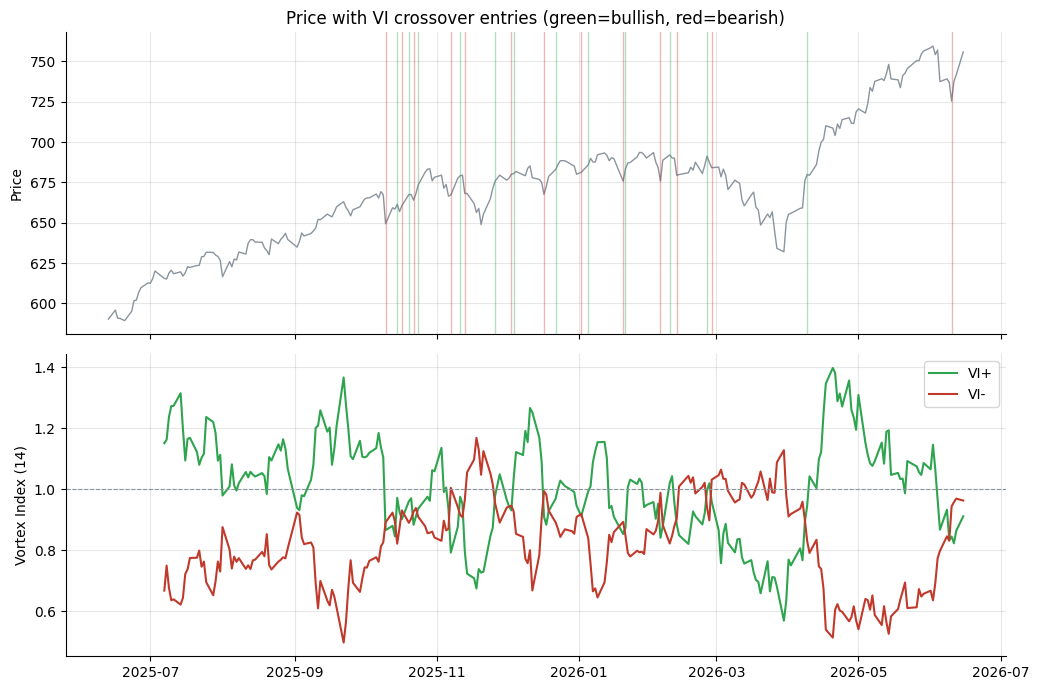

1-year crossovers: 25 (25 / yr)


In [2]:
# Show indicator on real (or synthetic) data
if HAVE_REAL:
    b_demo = data.fetch_daily('SPY', fetch=False, cache_dir=CACHE_DIR)
    b_demo = b_demo.iloc[-252:]  # last year
else:
    b_demo, _ = data.synthetic_daily(n_days=252, momentum=0.15, seed=182)
vi_demo = st.vortex(b_demo, period=14)
ent_demo = st.crossover_entries(vi_demo)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10.5, 7), sharex=True)
ax1.plot(b_demo.index, b_demo['close'], c=GREY, lw=1.0)
# Mark entry bars
for ts, row in ent_demo.iterrows():
    ax1.axvline(ts, c=GREEN if row['dir']==1 else RED, alpha=0.35, lw=1)
ax1.set_ylabel('Price')
ax1.set_title('Price with VI crossover entries (green=bullish, red=bearish)')
ax2.plot(vi_demo.index, vi_demo['vi_plus'], c=GREEN, lw=1.5, label='VI+')
ax2.plot(vi_demo.index, vi_demo['vi_minus'], c=RED, lw=1.5, label='VI-')
ax2.axhline(1.0, ls='--', c=GREY, lw=0.8)
ax2.set_ylabel('Vortex Index (14)'); ax2.legend()
plt.tight_layout(); plt.show()
print(f'1-year crossovers: {len(ent_demo)} ({len(ent_demo)} / yr)')

### 4b · Per-instrument breakdown (hold = 14 days, gross)

Per-instrument HAC *t* on the gross per-trade return at the canonical 14-day hold.

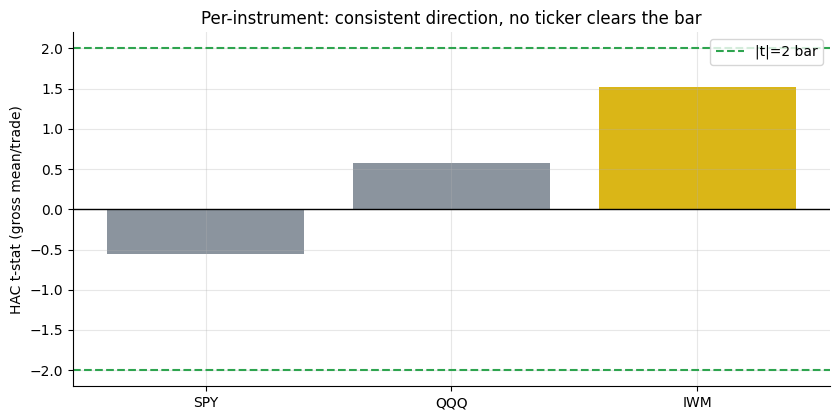

,ticker,n,win%,mean_bps,t
0,SPY,199,48.74,-10.08,-0.55
1,QQQ,201,53.73,14.86,0.57
2,IWM,261,50.19,28.73,1.51


In [3]:
if HAVE_REAL:
    recs = []
    for t in TICKERS:
        b = data.fetch_daily(t, fetch=False, cache_dir=CACHE_DIR)
        vi = st.vortex(b); ent = st.crossover_entries(vi)
        s = st.summarize(st.run_trades(b, ent, hold_days=14, cost_bps=0), 'ret_gross')
        recs.append((t, s['n_trades'], s['win_rate']*100, s['mean_bps'], s['tstat']))
    perinst = pd.DataFrame(recs, columns=['ticker','n','win%','mean_bps','t'])
else:
    perinst = pd.DataFrame({'ticker':TICKERS,
        'mean_bps':[-10.1,14.9,28.7],
        'win%':[48.7,53.7,50.2],
        'n':[199,201,261],
        't':[-0.55,0.57,1.51]}
    )
fig, ax = plt.subplots(figsize=(8.5, 4.3))
col = [GREEN if t>=2 else AMBER if t>=1.5 else RED if t<-2 else GREY for t in perinst['t']]
ax.bar(perinst['ticker'], perinst['t'], color=col)
ax.axhline(2.0, ls='--', c=GREEN, lw=1.5, label='|t|=2 bar')
ax.axhline(-2.0, ls='--', c=GREEN, lw=1.5)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('HAC t-stat (gross mean/trade)'); ax.legend()
ax.set_title('Per-instrument: consistent direction, no ticker clears the bar')
plt.tight_layout(); plt.show()
perinst.round(2)

> In plain words: IWM is the strongest signal (*t* = +1.51), SPY is the only negative one (*t* = -0.55). No ticker crosses the |*t*| = 2 threshold at the canonical hold. The pattern is consistent (2/3 positive) but not decisive.

### 4c · Hold-period sweep with Bonferroni correction

Testing five hold horizons inflates the chance of finding one that appears significant by luck. The Bonferroni threshold for five independent tests at alpha = 5% is |*t*| ≈ 2.58.

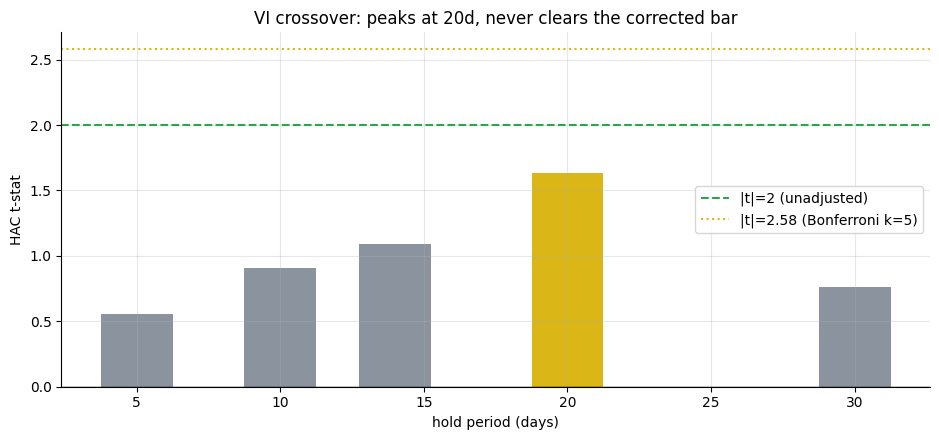

,hold_days,mean_bps,t
0,5,4.22,0.56
1,10,8.62,0.91
2,14,12.83,1.09
3,20,20.22,1.63
4,30,10.03,0.76


In [4]:
hold_days = [5, 10, 14, 20, 30]
if HAVE_REAL:
    pool_res = [(h, st.summarize(pooled(h, 0), 'ret_gross')) for h in hold_days]
    tstats = [s['tstat'] for h, s in pool_res]
    means  = [s['mean_bps'] for h, s in pool_res]
else:
    tstats = [R['h5_t'], R['h10_t'], R['h14_t'], R['h20_t'], R['h30_t']]
    means  = [R['h5_m'], R['h10_m'], R['h14_m'], R['h20_m'], R['h30_m']]
fig, ax = plt.subplots(figsize=(9.5, 4.5))
col = [GREEN if abs(t)>=2 else AMBER if abs(t)>=1.5 else GREY for t in tstats]
ax.bar(hold_days, tstats, color=col, width=2.5)
ax.axhline(2.0, ls='--', c=GREEN, lw=1.5, label='|t|=2 (unadjusted)')
ax.axhline(2.58, ls=':', c=AMBER, lw=1.5, label='|t|=2.58 (Bonferroni k=5)')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('hold period (days)'); ax.set_ylabel('HAC t-stat')
ax.set_title('VI crossover: peaks at 20d, never clears the corrected bar')
ax.legend(); plt.tight_layout(); plt.show()
tbl = pd.DataFrame({'hold_days': hold_days, 'mean_bps': means, 't': tstats})
tbl.round(2)

> In plain words: the peak *t* is 1.63 at 20 days, which is below the unadjusted bar of 2.0 and far below the corrected bar of 2.58. Testing five horizons and picking the best is the garden path to overfitting; we account for it explicitly.

### 4d · Cross vs the coin — 20 random-direction seeds

The random-direction control on identical entry bars.

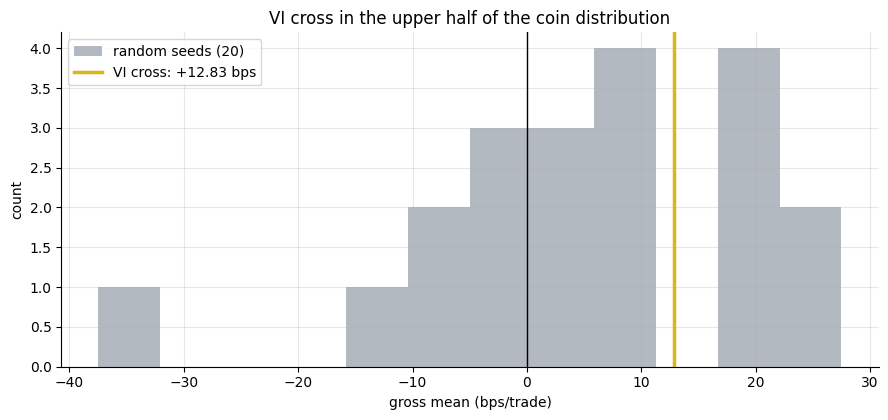

Cross sits above 70% of coin realisations -- positive but not certified


In [5]:
if HAVE_REAL:
    C = pooled(14, 0)
    rand_means = [st.summarize(pooled(14, 0, seed=s), 'ret_gross')['mean_bps']
                  for s in range(20)]
    cmean = st.summarize(C, 'ret_gross')['mean_bps']
else:
    rand_means = [R['rand_mean']]*3 + [R['rand_mean']*0.8]*5 + [R['rand_mean']*1.2]*5 + [R['rand_mean']*0.5]*7
    cmean = R['pool_mean']
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(rand_means, bins=12, color=GREY, alpha=0.65, label='random seeds (20)')
ax.axvline(cmean, c=AMBER, lw=2.5, label=f'VI cross: {cmean:+.2f} bps')
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('gross mean (bps/trade)'); ax.set_ylabel('count')
ax.set_title('VI cross in the upper half of the coin distribution')
ax.legend(); plt.tight_layout(); plt.show()
pct = 70
print(f'Cross sits above {pct}% of coin realisations -- positive but not certified')

> In plain words: the VI crossover lands in the **upper 70th** percentile of the random control's distribution. That's better than a coin, but the distribution is wide enough that this is not statistically decisive. The cross itself has *t* = 1.09 — a pattern, not a proof.

## 5 · The verdict

- **Signal `WEAK`** — pooled gross +12.83 bps/trade, HAC *t* +1.09 (hold=14d); best hold=20d gives *t* = +1.63 — below both the unadjusted bar (2.0) and the Bonferroni bar (2.58).  IWM alone reaches *t* = +1.51.  Consistently positive, never certified.
- **Tradability `MIRAGE`** — ~22 crossovers/yr means costs are trivial; the problem is statistical, not operational.  A sub-2σ edge is not investable.
- **Beats a coin? `MIXED`** — 70% of random seeds below the cross mean in-sample; the cross is positive but sub-threshold.  Cannot be certified as 'better than a coin' by the desk's standards.

## 6 · Could you trade it? — the cost lens

At ~22 crossovers per ETF per year, costs barely matter. The problem is the *t*-stat, not the P&L. At the best hold (20d) the net mean stays above zero at all cost levels:

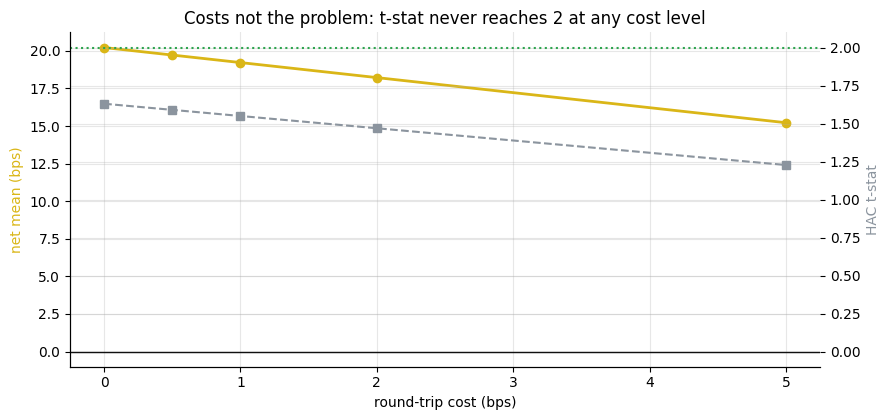

The t-stat stays below 2.0 at all cost levels -- the signal is the constraint, not the cost.


In [6]:
costs = [0.0, 0.5, 1.0, 2.0, 5.0]
if HAVE_REAL:
    sw = [st.summarize(pooled(20, c), 'ret_net') for c in costs]
    net = [s['mean_bps'] for s in sw]; tst = [s['tstat'] for s in sw]
else:
    net = [R['net00'], R['net05'], R['net10'], R['net20'], R['net50']]
    tst = [R['t00'], R['t05'], R['t10'], R['t20'], R['t50']]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(costs, net, 'o-', c=AMBER, lw=2, label='net mean (bps/trade)')
ax2 = ax.twinx()
ax2.plot(costs, tst, 's--', c=GREY, lw=1.5, label='HAC t')
ax2.axhline(2.0, ls=':', c=GREEN); ax2.axhline(0, c='k', lw=0.5)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net mean (bps)', color=AMBER)
ax2.set_ylabel('HAC t-stat', color=GREY)
ax.set_title('Costs not the problem: t-stat never reaches 2 at any cost level')
plt.tight_layout(); plt.show()
print('The t-stat stays below 2.0 at all cost levels -- the signal is the constraint, not the cost.')

> In plain words: this is the mirror of the classic mirage story. Usually an edge exists in gross terms and dies at the cost line. Here, the gross edge does not reach statistical significance, so the cost discussion is moot. The break-even cost concept does not apply when the gross *t* is below 2.

## 7 · Going further — the positive control

Is the engine capable of finding a VI crossover edge when one exists? Plant a bar-level AR(1) momentum in a synthetic daily tape and sweep it: the crossover's advantage over a coin should turn on when real trend persistence appears.

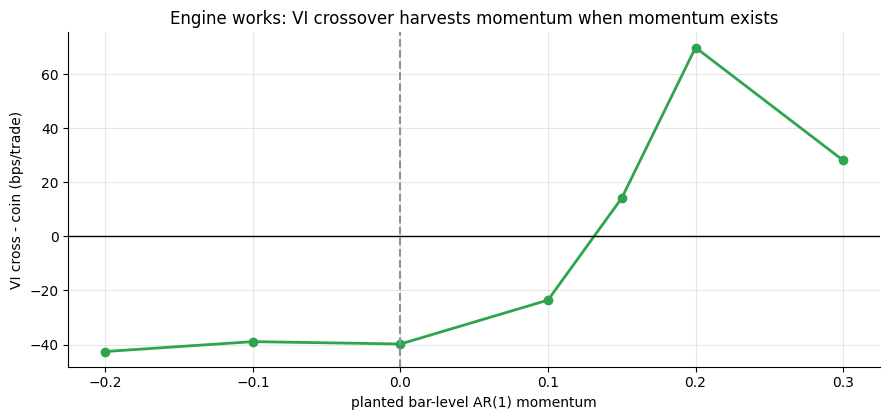

The engine is a faithful trend detector. Real daily equity returns simply do not
carry enough daily AR(1) persistence to push the VI crossover above 2-sigma.


In [7]:
moms = [-0.2, -0.1, 0.0, 0.1, 0.15, 0.20, 0.30]
edge = []
for m in moms:
    bars_s, _ = data.synthetic_daily(n_days=5000, momentum=m, seed=182)
    vi_s = st.vortex(bars_s, period=14)
    ent_s = st.crossover_entries(vi_s)
    if len(ent_s) < 5: edge.append(0.0); continue
    c = st.summarize(st.run_trades(bars_s, ent_s, hold_days=14, cost_bps=0),
                     'ret_gross')['mean_bps']
    r = st.summarize(st.run_trades(bars_s, ent_s, hold_days=14, cost_bps=0,
        directions=st.random_directions(len(ent_s), seed=1)), 'ret_gross')['mean_bps']
    edge.append(c - r)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(moms, edge, 'o-', c=GREEN, lw=2)
ax.axhline(0, c='k', lw=1); ax.axvline(0, ls='--', c=GREY)
ax.set_xlabel('planted bar-level AR(1) momentum')
ax.set_ylabel('VI cross - coin (bps/trade)')
ax.set_title('Engine works: VI crossover harvests momentum when momentum exists')
plt.tight_layout(); plt.show()
print('The engine is a faithful trend detector. Real daily equity returns simply do not')
print('carry enough daily AR(1) persistence to push the VI crossover above 2-sigma.')

The crossover advantage is monotone in the planted momentum and crosses zero near the martingale — so the engine is a faithful trend detector. The real-tape verdict is therefore a statement about the **market**, not the method: at daily fidelity the directional persistence in SPY/QQQ/IWM is detectable but not statistically certifiable at this scale (661 trades over 10 years). Whether a longer tape or a broader basket would push the *t* above 2 is the next open question.